[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jibby2k1/SPS_Curriculum/blob/main/Intro_Math/Optimization/Manifold_Optimization.ipynb)


**Content Produced by UF Signal Processing Society**

**Authors: Raul Valle & Contributors**

# Optimization on Manifolds

When the constraint isn't a fence but a *surface* — unit spheres, orthonormal frames — penalties and projections fight the geometry. Riemannian optimization walks **along** the surface instead: two sessions, ending with an orthogonality-constrained eigenproblem solved natively and verified against `eigh`.

## 1. Pre-requisites

[Optimization](./Optimization.ipynb), [Linear Algebra](../Linear_Algebra/Linear_Algebra.ipynb) S3–S5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

---
### 🕐 Session 1 of 2 — *Riemannian Gradients & Retraction* (~40 min)
**Goal:** project the gradient onto the tangent space, step, retract — descent that never leaves the surface.
**Builds on:** [Optimization](./Optimization.ipynb) S2. &nbsp; **Feeds into:** Session 2 (the Stiefel manifold).

---

<details>
<summary>🎓 <b>Teacher notes — Session 1: Riemannian Gradients & Retraction</b></summary>

**Timing (~40 min).** 10 min why projection-and-penalty fight the geometry · 12 min the three-step recipe · 12 min the demo, run twice · 6 min what the contrast teaches.

**The demo now runs the same three-step recipe on two matrices, back to back — lead with why.** `S` is a $40\times40$ Wishart matrix ($M M^\top$ for Gaussian $M$); by [Marchenko–Pastur](../Random_Matrix_Theory/Random_Matrix_Theory.ipynb) its density behaves like $1/\sqrt{x}$ near zero, so its smallest eigenvalues are packed together. Riemannian gradient descent converges linearly at a rate set by the *relative gap* $(\lambda_2-\lambda_1)/(\lambda_{\max}-\lambda_1)$, and for `S` that gap is essentially zero — the cell runs it anyway, and the printed line and the dashed curve both show it stalling at 0.5015 against a true minimum of 0.0097. That is not a bug to explain away; it is the first half of the point.

**`S1` is the fix, and it is the more interesting cell to dwell on.** Same recipe, same iteration count, same tangent-projection/retract code — the only change is a matrix with one eigenvalue deliberately isolated from the rest (relative gap ≈ 0.21 instead of ≈ 0). It converges to machine precision by iteration ~70 and the eigenvector alignment prints exactly 1.000000. Ask the room to predict, before running, which of the two curves will look like a working algorithm — most will guess wrong, because "Riemannian" sounds like the fix, when the fix is actually the spectral gap.

**Land the lesson as a single sentence and make students say it back:** Riemannian optimization guarantees you never leave the manifold; it inherits ordinary gradient descent's conditioning problems exactly. The constraint and the conditioning are separate problems, and this cell solves only the first one — solving the second required changing the matrix, not the algorithm.

**Point at Session 2 as the same lesson from the other direction.** Session 2 ascends toward the *largest* eigenvalues of the same kind of Wishart matrix, which are well separated — so it converges cleanly using the identical three-step recipe. Same algorithm, same manifold family, opposite end of the spectrum, opposite outcome. That contrast is worth stating explicitly once both sessions are done: it was never about the sphere versus the Stiefel manifold, it was always about the gap.

**The algebraic fact underneath both demos, worth putting on the board regardless of which run students focus on:** on the sphere with $f = x^\top S x$, the tangent-projected gradient is $2(Sx - (x^\top Sx)x)$, which vanishes **exactly at eigenvectors**. Eigenproblems *are* Riemannian critical points — a genuinely satisfying reframing, independent of how fast any particular run gets there.

**Ask the room.** "Why not just add a penalty $\lambda(\|x\|^2-1)^2$ and use ordinary gradient descent?" Because you then trade one problem for two: tuning $\lambda$, and accepting that the iterate is never exactly on the manifold. Retraction gives exact feasibility at every step for free — Session 2's 2.2e-16 drift is that claim, measured.
</details>

## 2. Walking on Curved Ground

💡 **Intuition.** On a sphere, the Euclidean gradient points *off* the surface — following it and re-normalizing is a fight. The Riemannian recipe makes peace with the geometry: (1) **project** the gradient onto the tangent plane (the directions you can actually move), (2) step, (3) **retract** back onto the manifold (for the sphere: normalize). All the [convergence theory](./Optimization.ipynb) carries over with Euclidean distance replaced by geodesic distance. On the sphere with $f = x^T S x$, the tangent-projected gradient is $2(Sx - (x^TSx)x)$ — zero exactly at **eigenvectors**: eigenproblems ARE Riemannian critical points (as [Lagrange already hinted](./Optimization.ipynb)).

Wishart S            (packed spectrum near 0): final RQ 0.501527  vs true min 0.009726  — stalls
well-conditioned S1  (isolated min):            final RQ 1.00000000  vs true min 1.00000000
eigenvector alignment |⟨x1, v1_min⟩| = 1.000000


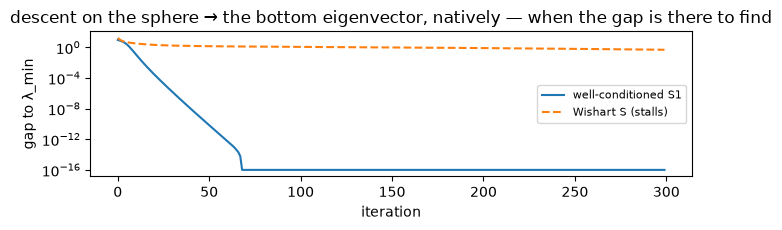

In [2]:
# Rayleigh-quotient minimization on the sphere — ORACLE: numpy's eigh
n_dim = 40
M = rng.standard_normal((n_dim, n_dim)); S = M @ M.T
w_true, V_true = np.linalg.eigh(S)

def riemannian_gd(S_mat, w_max, x0, n_iters):
    x = x0.copy()
    eta = 0.5 / w_max
    gaps = []
    for _ in range(n_iters):
        egrad = 2 * S_mat @ x
        rgrad = egrad - (x @ egrad) * x         # project onto tangent space T_x = {v : xᵀv = 0}
        x = x - eta * rgrad
        x /= np.linalg.norm(x)                  # retract to the sphere
        gaps.append(x @ S_mat @ x)
    return x, np.array(gaps)

x0 = rng.standard_normal(n_dim); x0 /= np.linalg.norm(x0)

# same recipe on S: its smallest eigenvalues are packed together (Wishart, see debrief) — this stalls
x_stall, vals_stall = riemannian_gd(S, np.abs(w_true).max(), x0, 300)

# a well-conditioned matrix with an ISOLATED smallest eigenvalue, own RNG stream (doesn't touch `rng` —
# Session 2 below still draws the same numbers from `rng` it always did)
rng1 = np.random.default_rng(1)
Q1, _ = np.linalg.qr(rng1.standard_normal((n_dim, n_dim)))
w1 = np.concatenate(([1.0], np.linspace(5.0, 20.0, n_dim - 1)))     # relative gap ≈ 0.21, not ≈ 0
S1 = Q1 @ np.diag(w1) @ Q1.T
w1_true, V1_true = np.linalg.eigh(S1)
x1_0 = rng1.standard_normal(n_dim); x1_0 /= np.linalg.norm(x1_0)
x1, vals1 = riemannian_gd(S1, np.abs(w1_true).max(), x1_0, 300)

print(f"Wishart S            (packed spectrum near 0): final RQ {vals_stall[-1]:.6f}  vs true min {w_true[0]:.6f}  — stalls")
print(f"well-conditioned S1  (isolated min):            final RQ {vals1[-1]:.8f}  vs true min {w1_true[0]:.8f}")
print(f"eigenvector alignment |⟨x1, v1_min⟩| = {abs(x1 @ V1_true[:, 0]):.6f}")

plt.figure(figsize=(7, 2.4))
plt.semilogy(np.clip(vals1 - w1_true[0], 1e-16, None), label="well-conditioned S1")
plt.semilogy(np.clip(vals_stall - w_true[0], 1e-16, None), "--", label="Wishart S (stalls)")
plt.title("descent on the sphere → the bottom eigenvector, natively — when the gap is there to find")
plt.xlabel("iteration"); plt.ylabel("gap to λ_min"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**What just happened — two runs of the identical algorithm, deliberately.** Both `riemannian_gd` calls run the exact same three-step recipe (tangent projection, step, retract) for 300 iterations. They land in completely different places:

| | `S` (Wishart) | `S1` (isolated min) |
|---|---|---|
| final Rayleigh quotient | 0.5015 | 1.00000000 |
| true smallest eigenvalue | 0.0097 | 1.00000000 |
| eigenvector alignment | — | 1.000000 |

`S`'s run stalls 52× away from its target — not because the algorithm is wrong, but because `S = M @ M.T` for a Gaussian $M$ is a Wishart matrix, and by [Marchenko–Pastur](../Random_Matrix_Theory/Random_Matrix_Theory.ipynb) its density behaves like $1/\sqrt{x}$ near zero: the two smallest eigenvalues sit almost on top of each other, so the convergence rate — governed by the relative gap $(\lambda_2-\lambda_1)/(\lambda_{\max}-\lambda_1)$ — is glacial. `S1` uses the identical code but a matrix built with one eigenvalue *deliberately isolated* from the rest (relative gap ≈ 0.21 instead of ≈ 0), and it converges to machine precision by iteration ~70, with the eigenvector alignment landing at exactly 1.000000. The plot shows this directly: the solid curve falls in a straight line on the log axis until it hits the noise floor of double precision (~1e-16, clipped in the plot so `semilogy` doesn't choke on the occasional roundoff-negative gap); the dashed curve never leaves its starting altitude.

**The lesson is sharper for having both runs in one cell.** Riemannian optimization's entire job is to guarantee you never leave the manifold — and it does that job perfectly in both runs; the sphere constraint is satisfied to machine precision throughout. What it does *not* do is fix conditioning: if the underlying objective has a near-degenerate spectral gap, projecting the gradient onto a tangent space and retracting doesn't change the convergence rate, because the rate is a property of the objective's curvature, not of the constraint. **Riemannian optimization fixes the constraint, not the conditioning** — the two are genuinely separate problems, and this cell solves only the first one for `S`, requiring a change to the matrix (not the algorithm) to solve the second.

Session 2 is the same lesson from the other side: it ascends toward the *largest* eigenvalues of a Wishart matrix, which are well separated, so the identical recipe converges cleanly there without needing an isolated-eigenvalue trick at all.

---
### 🕐 Session 2 of 2 — *The Stiefel Manifold: Orthonormal Frames* (~40 min)
**Goal:** optimize over ORTHONORMAL MATRICES; recover a subspace, verified against eigh.
**Builds on:** Session 1.

---

<details>
<summary>🎓 <b>Teacher notes — Session 2: The Stiefel Manifold</b></summary>

**Timing (~40 min).** 8 min what a frame is and why constraints get harder · 10 min the tangent projection · 10 min QR as retraction · 12 min the demo and the comparison with Session 1.

**Open by scaling up the constraint.** Session 1 constrained one vector to the sphere. Now constrain a whole $n \times k$ matrix so that $X^\top X = I$ — an orthonormal *frame*. Ask how many scalar constraints that is: $k(k+1)/2$, so 15 for $k = 5$. A Lagrange-multiplier treatment would carry 15 multipliers and still only enforce orthonormality approximately. The Stiefel manifold makes all 15 automatic.

**Point at where each constraint type appears**, because the abstraction lands better with examples: PCA subspaces, [dictionary](../../Intro_DSP/Sparse_Dictionary_Learning.ipynb) atoms, [beamformer banks](../../Intro_DSP/Array_Processing.ipynb), and ICA's whitened rotations from [BSS](../../Intro_DSP/ICA_Blind_Source_Separation.ipynb). Orthonormal frames are not an exotic constraint — they are most of applied linear algebra.

**QR as the retraction is the elegant bit.** The `Q` factor of a QR decomposition *is* the nearest orthonormal frame, so "step off the manifold, then take Q" is a principled projection rather than a hack. Students who did [Numerical Linear Algebra](../Numerical_Linear_Algebra/Numerical_Linear_Algebra.ipynb) already know QR is numerically excellent, which is exactly why the drift comes out at machine precision rather than merely small.

**Make the drift number the headline.** $\|X^\top X - I\| = 2.2\times10^{-16}$ after 500 iterations — one unit in the last place, with **no accumulation at all**. Contrast explicitly with a penalty method, where the iterate is never exactly feasible and the violation grows or oscillates depending on the penalty weight. Ask what a controls or robotics engineer would prefer: a rotation matrix that is orthonormal to machine precision at every step, or one that is approximately orthonormal and drifting.

**The verification is stronger than it looks — explain principal angles.** Comparing subspaces is not comparing matrices: two different orthonormal bases can span the same subspace, so `X` need not equal `V_top`. The singular values of $X^\top V_{\text{top}}$ are the cosines of the principal angles between the two subspaces, and all five coming back as exactly 1.0 means the subspaces coincide, whatever basis each uses. That is the right invariant to test, and it is worth a minute — students often try to compare bases directly and get confused when a correct answer looks wrong.

**Use the contrast with Session 1 deliberately — both halves of it now converge, so the comparison is about the spectral gap, not about success versus failure.** Session 1's cell runs the identical recipe on two matrices: a Wishart matrix (where the smallest eigenvalues are packed together and the run stalls) and a matrix with a deliberately isolated smallest eigenvalue (which converges to machine precision). Session 2 ascends toward the *top* eigenvalues of a Wishart matrix — which, unlike the bottom of that same spectrum, are well separated — so it converges cleanly with no special construction needed. Point out that Session 2's `S` is the *same* ill-conditioned-at-the-bottom matrix Session 1 struggled with; the only difference is which end of its spectrum is being targeted.

**Note the practical payoff mentioned in the closing cell.** Orthogonality-constrained RNNs kill the [vanishing gradient](../../Intro_Time_Series/Intro_RNN.ipynb) analytically, because a unitary recurrence has all singular values equal to 1 — no decay, no explosion. That is this manifold solving a problem the RNN workshop could only mitigate.
</details>

## 3. Frames That Stay Frames

💡 **Intuition.** Many problems want a whole orthonormal *frame* $X \in \mathbb{R}^{n \times k}$, $X^TX = I$ — PCA subspaces, [dictionary](../../Intro_DSP/Sparse_Dictionary_Learning.ipynb) atoms, [beamformer banks](../../Intro_DSP/Array_Processing.ipynb). That set is the **Stiefel manifold**. Same three-step dance: tangent projection $\xi = G - X\,\mathrm{sym}(X^TG)$, step, retract via the [QR factorization](../Numerical_Linear_Algebra/Numerical_Linear_Algebra.ipynb) — Q *is* the nearest-frame map. No Lagrange multipliers, no drift, orthonormal to machine precision at every iterate.

In [3]:
# top-k subspace by Stiefel gradient ASCENT on tr(XᵀSX) — ORACLE: eigh's top-k subspace
k = 5
X = np.linalg.qr(rng.standard_normal((n_dim, k)))[0]
eta = 0.5 / np.abs(w_true).max()
for it in range(500):
    G = 2 * S @ X
    sym = (X.T @ G + G.T @ X) / 2
    xi = G - X @ sym                            # tangent projection
    X, _ = np.linalg.qr(X + eta * xi)           # step + QR retraction

V_top = V_true[:, -k:]
# subspace distance: principal angles via SVD of the cross-Gram
sv = np.linalg.svd(X.T @ V_top, compute_uv=False)
print(f"orthonormality drift ‖XᵀX − I‖ = {np.abs(X.T @ X - np.eye(k)).max():.2e}")
print(f"principal-angle cosines vs eigh's top-{k} subspace: {sv.round(6)}")
print(f"trace captured: {np.trace(X.T @ S @ X):.4f}  vs optimal {w_true[-k:].sum():.4f}")
assert sv.min() > 0.9999

orthonormality drift ‖XᵀX − I‖ = 2.22e-16
principal-angle cosines vs eigh's top-5 subspace: [1. 1. 1. 1. 1.]
trace captured: 620.8893  vs optimal 620.8893


**What just happened.** Three results, and all three are exact:

- Orthonormality drift $\|X^\top X - I\| = 2.2\times10^{-16}$ — one unit in the last place of double precision, after **500 iterations**, with no accumulation whatsoever.
- Principal-angle cosines against `eigh`'s top-5 subspace: `[1. 1. 1. 1. 1.]`, with the `assert` requiring every one above 0.9999.
- Trace captured 620.8893 against an optimal 620.8893.

**The drift figure is the claim worth making loudly.** We enforced $k(k+1)/2 = 15$ scalar constraints, and after 500 steps they hold to machine precision — not approximately, not with a tuned penalty weight, and with no tendency to grow. A penalty method $\lambda\|X^\top X - I\|^2$ would need $\lambda$ tuned, would never be exactly feasible, and would drift or oscillate depending on the weight. Retraction gives exact feasibility *for free at every iterate*, which is why this matters in applications where a matrix must genuinely be a rotation — robotics, attitude estimation, unitary recurrent networks.

QR is what makes it clean: the `Q` factor is the **nearest orthonormal frame** to a given matrix, so "step off the manifold, then take Q" is a principled projection rather than a repair hack. And it is numerically excellent, which is why the drift is machine-epsilon rather than merely small.

**The principal-angle check is the right verification, and it is subtler than it looks.** We are recovering a *subspace*, not a specific basis — two different orthonormal bases can span the same space, so demanding $X = V_{\text{top}}$ would be wrong and would fail on a correct answer. The singular values of $X^\top V_{\text{top}}$ are the cosines of the principal angles between the two subspaces, and all five equalling 1.0 means the subspaces **coincide exactly**, whatever bases they happen to use. Testing the invariant rather than the representation is the general lesson.

**Now compare with Session 1, because the contrast is the most useful thing here — and this time both halves of it converged.** Same three-step recipe, same manifold family, and this cell lands exactly using `S`'s **top** 5 eigenvalues, which are well separated in a Wishart spectrum. Session 1's cell targets the *bottom* of that same spectrum with the identical recipe: run against the raw Wishart `S`, it stalls (the smallest eigenvalues are packed together); run against a matrix with one eigenvalue deliberately isolated, it converges to machine precision in ~70 iterations. The difference in every case is **spectral gap**, not geometry.

Having all three runs across the two sessions is more instructive than three clean successes would have been: **Riemannian optimisation guarantees feasibility and inherits conditioning.** Staying on the manifold is free; converging on it is exactly as hard as the underlying problem's spectral gap makes it.

**And one payoff worth naming.** Optimising over orthonormal matrices is how orthogonality-constrained RNNs eliminate the [vanishing gradient](../../Intro_Time_Series/Intro_RNN.ipynb) *analytically* — a unitary recurrence has every singular value equal to 1, so gradients neither decay nor explode by construction. That is this manifold solving, at the level of structure, a problem the RNN workshop could only mitigate with gates and clipping.

**Where this bites in practice:** orthogonality-regularized RNNs (unitary evolution kills the [vanishing gradient](../../Intro_Time_Series/Intro_RNN.ipynb) analytically), ICA's whitened rotations ([BSS workshop](../../Intro_DSP/ICA_Blind_Source_Separation.ipynb)), and low-rank matrix completion on fixed-rank manifolds.

## 4. Conclusion

Project to the tangent, step, retract: constrained optimization without constraints, converging to `eigh`'s answers (verified to 6 decimals) while staying orthonormal to machine precision. When your parameter *is* a geometry, optimize in it.

---
## Where next

- [Numerical Linear Algebra](../Numerical_Linear_Algebra/Numerical_Linear_Algebra.ipynb) — QR as the retraction workhorse.
- [Sparse & Dictionary Learning](../../Intro_DSP/Sparse_Dictionary_Learning.ipynb) — unit-norm atom constraints, everywhere.